# Part 5 — Covariate Engineering

**7PAM2033 Applied Machine Learning — Assignment 2**

> **Task:** Add sensor, weather, and time-based covariates to improve the
> modelling, including indoor temperature, humidity, outdoor weather
> variables, time-of-day features, day-of-week features, and lagged
> appliance-use features. These features are included in the dataset, but you
> will also need to define some additional ones from this data.

This notebook builds the feature table that Part 6 consumes. No models are
fitted here.

**The governing constraint is the 24-hour horizon.** A feature is only
legitimate if its value is knowable at the moment the forecast is made. That
rules out the previous hour's appliance reading, the current outdoor
temperature, and any rolling window that touches the forecast period. Getting
this wrong is the single most common way to produce impressive and worthless
results, and it is what Question 5 of the report is about.

Two feature sets are therefore built, corresponding to the regimes fixed in
Part 2:

| Regime | Contents | What it measures |
|---|---|---|
| **A — operational** | Calendar terms, target lags ≥ 24 h, sensor and weather lags ≥ 24 h | Accuracy achievable in deployment |
| **B — conditional** | Regime A plus realised sensor and weather values during the forecast window | Upper bound assuming perfect weather knowledge |


## 1. Setup


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

BASE_DIR = Path.cwd()
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"
RAW_FILE = BASE_DIR / "energydata_complete.csv"
RAW_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00374/energydata_complete.csv")

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
PROCESSED_DIR = BASE_DIR / "outputs" / "processed"
for directory in (FIGURE_DIR, METRICS_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6

_PV = tuple(int(p) for p in pd.__version__.split(".")[:2])
HOURLY_FREQ = "h" if _PV >= (2, 2) else "H"

DAILY_PERIOD, WEEKLY_PERIOD = 24, 168
HORIZON, TEST_DAYS = 24, 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD

INDOOR_TEMP = [f"T{i}" for i in range(1, 10)]
INDOOR_RH = [f"RH_{i}" for i in range(1, 10)]
WEATHER = ["T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility",
           "Tdewpoint"]

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"

print(f"Horizon {HORIZON}h - minimum admissible lag is {HORIZON} hours")


Horizon 24h - minimum admissible lag is 24 hours


In [2]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq(HOURLY_FREQ)

    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)
    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])
    counts = raw.resample(HOURLY_FREQ).size()
    hourly = raw.resample(HOURLY_FREQ).mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET]); hourly.to_csv(HOURLY_FILE)
    return hourly


hourly = load_hourly()
series = hourly[TARGET]

print(f"Observations : {len(hourly)}")
print(f"Raw columns  : {hourly.shape[1]}")
print(f"Range        : {hourly.index.min()} to {hourly.index.max()}")


Observations : 3289
Raw columns  : 26
Range        : 2016-01-11 17:00:00 to 2016-05-27 17:00:00


## 2. Time-based features

Calendar terms are the only features knowable with certainty for any future
timestamp, since they are deterministic functions of the clock. They cost
nothing and carry no leakage risk.

Hour and day-of-week are encoded three ways, because tree models and linear
models want different things:

- **Integer** `hour` and `dayofweek` — tree models split on these directly and
  can carve out arbitrary blocks such as "18:00 to 20:00".
- **Cyclical sine and cosine pairs** — these tell a linear model that hour 23
  is adjacent to hour 0, which integer encoding cannot express. Three
  harmonics are used for the hour because Part 1 showed the daily profile is
  bimodal, with a late-morning plateau and an evening peak; a single harmonic
  can only describe one peak.
- **Binary flags** for weekend and for the evening peak window, which make the
  most important distinctions explicit rather than leaving them to be
  discovered.


In [3]:
def add_time_features(frame):
    """Deterministic calendar features, valid for any future timestamp."""
    out = pd.DataFrame(index=frame.index)
    index = frame.index

    out["hour"] = index.hour
    out["dayofweek"] = index.dayofweek
    out["day_of_month"] = index.day
    out["week_of_year"] = index.isocalendar().week.astype(int).to_numpy()
    out["is_weekend"] = (index.dayofweek >= 5).astype(int)

    # Three harmonics describe the bimodal daily profile found in Part 1
    for k in (1, 2, 3):
        out[f"hour_sin{k}"] = np.sin(2 * np.pi * k * index.hour / 24)
        out[f"hour_cos{k}"] = np.cos(2 * np.pi * k * index.hour / 24)

    out["dow_sin"] = np.sin(2 * np.pi * index.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * index.dayofweek / 7)

    # Explicit flags for the regimes visible in the Part 1 profile plot
    out["is_evening_peak"] = index.hour.isin([17, 18, 19]).astype(int)
    out["is_overnight"] = index.hour.isin([0, 1, 2, 3, 4, 5]).astype(int)
    out["is_morning_ramp"] = index.hour.isin([6, 7, 8, 9]).astype(int)

    return out


time_features = add_time_features(hourly)
print(f"{time_features.shape[1]} time-based features")
print(list(time_features.columns))
time_features.head(3)


16 time-based features
['hour', 'dayofweek', 'day_of_month', 'week_of_year', 'is_weekend', 'hour_sin1', 'hour_cos1', 'hour_sin2', 'hour_cos2', 'hour_sin3', 'hour_cos3', 'dow_sin', 'dow_cos', 'is_evening_peak', 'is_overnight', 'is_morning_ramp']


,hour,dayofweek,day_of_month,week_of_year,is_weekend,hour_sin1,hour_cos1,hour_sin2,hour_cos2,hour_sin3,hour_cos3,dow_sin,dow_cos,is_evening_peak,is_overnight,is_morning_ramp
date,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,17,0,11,2,0,-0.965926,-2.588190e-01,5.000000e-01,-0.866025,0.707107,7.071068e-01,0.0,1.0,1,0,0
2016-01-11 18:00:00,18,0,11,2,0,-1.000000,-1.836970e-16,3.673940e-16,-1.000000,1.000000,5.510911e-16,0.0,1.0,1,0,0
2016-01-11 19:00:00,19,0,11,2,0,-0.965926,2.588190e-01,-5.000000e-01,-0.866025,0.707107,-7.071068e-01,0.0,1.0,1,0,0


## 3. Lagged appliance-use features

The target's own history is the strongest predictor available, but at a
24-hour horizon most of it is out of reach. When a forecast is issued at
17:00 for the following day, the most recent observation is already 24 hours
old by the time the last forecast hour arrives.

**Every target lag must therefore be at least 24 hours.** The lags chosen
correspond to structure identified in Part 1:

- 24, 25, 26 — the same hour yesterday and its neighbours, capturing the daily
  cycle with a little tolerance for timing shifts
- 48, 72 — two and three days back, useful when yesterday was atypical
- 168, 336 — the same hour one and two weeks ago, capturing the weekly cycle
  whose autocorrelation (0.306) matched the daily one

Rolling statistics are computed on a series already shifted by the full
horizon, so that no window can reach into the forecast period. The `.shift(24)`
before `.rolling()` is the entire safety mechanism, and section 6 tests it.


In [4]:
TARGET_LAGS = [24, 25, 26, 48, 72, 168, 336]
ROLLING_WINDOWS = [24, 72, 168]


def add_target_lags(frame, target=TARGET, horizon=HORIZON):
    """Lagged and rolling features from the target, all at least `horizon` old.

    The shift by `horizon` is applied before any rolling window, so no
    statistic can include an observation from the forecast period.
    """
    out = pd.DataFrame(index=frame.index)
    values = frame[target]

    for lag in TARGET_LAGS:
        if lag < horizon:
            raise ValueError(f"lag {lag} is shorter than the horizon {horizon}")
        out[f"lag_{lag}"] = values.shift(lag)

    safe = values.shift(horizon)

    for window in ROLLING_WINDOWS:
        out[f"roll_mean_{window}"] = safe.rolling(window).mean()
        out[f"roll_std_{window}"] = safe.rolling(window).std()
        out[f"roll_min_{window}"] = safe.rolling(window).min()
        out[f"roll_max_{window}"] = safe.rolling(window).max()

    # Demand at this hour of day averaged over the previous week, which is a
    # smoothed seasonal naive and less sensitive to one unusual day
    out["same_hour_mean_7d"] = (
        safe.groupby(frame.index.hour).transform(
            lambda s: s.rolling(7, min_periods=1).mean())
    )
    out["same_hour_std_7d"] = (
        safe.groupby(frame.index.hour).transform(
            lambda s: s.rolling(7, min_periods=1).std())
    )

    # Direction of travel between comparable points in previous cycles
    out["diff_24_48"] = out["lag_24"] - out["lag_48"]
    out["diff_24_168"] = out["lag_24"] - out["lag_168"]
    out["ratio_24_roll168"] = out["lag_24"] / (out["roll_mean_168"] + 1e-6)

    return out


target_features = add_target_lags(hourly)
print(f"{target_features.shape[1]} target-derived features")
print(f"Minimum lag used: {min(TARGET_LAGS)} hours (horizon is {HORIZON})")
print(list(target_features.columns))


24 target-derived features
Minimum lag used: 24 hours (horizon is 24)
['lag_24', 'lag_25', 'lag_26', 'lag_48', 'lag_72', 'lag_168', 'lag_336', 'roll_mean_24', 'roll_std_24', 'roll_min_24', 'roll_max_24', 'roll_mean_72', 'roll_std_72', 'roll_min_72', 'roll_max_72', 'roll_mean_168', 'roll_std_168', 'roll_min_168', 'roll_max_168', 'same_hour_mean_7d', 'same_hour_std_7d', 'diff_24_48', 'diff_24_168', 'ratio_24_roll168']


## 4. Sensor and weather features

The dataset supplies nine indoor temperature and nine indoor humidity
channels plus six outdoor weather variables. Part 1 found none of them
correlates strongly with the target — the largest is about 0.26 — so
individual raw channels are unlikely to carry much on their own.

Two things are therefore done with them.

**Aggregation.** Nine room temperatures are highly correlated with one
another and mostly describe the same thing: how warm the house is. Summaries
across rooms are more informative per parameter than nine near-duplicates, and
the *spread* between rooms is a genuinely new signal — a house with one hot
room is behaving differently from one that is uniformly warm.

**Derived physical quantities.** The difference between indoor and outdoor
temperature is a proxy for heating demand, and the gap between outdoor
temperature and dew point indicates how humid conditions feel. Both are more
directly meaningful than either input alone.

Every one of these is then lagged by the full horizon for Regime A, and also
retained unlagged for Regime B.


In [5]:
def add_sensor_features(frame):
    """Aggregate and derive from the raw sensor and weather channels."""
    out = pd.DataFrame(index=frame.index)

    temps = frame[INDOOR_TEMP]
    humidity = frame[INDOOR_RH]

    out["indoor_temp_mean"] = temps.mean(axis=1)
    out["indoor_temp_std"] = temps.std(axis=1)
    out["indoor_temp_range"] = temps.max(axis=1) - temps.min(axis=1)

    out["indoor_rh_mean"] = humidity.mean(axis=1)
    out["indoor_rh_std"] = humidity.std(axis=1)
    out["indoor_rh_range"] = humidity.max(axis=1) - humidity.min(axis=1)

    # Heating demand proxy: how hard the house is working against outside
    out["temp_gradient"] = out["indoor_temp_mean"] - frame["T_out"]
    out["rh_gradient"] = out["indoor_rh_mean"] - frame["RH_out"]

    # Dew point depression: how close outdoor air is to saturation
    out["dewpoint_depression"] = frame["T_out"] - frame["Tdewpoint"]

    # Kitchen and living room track cooking and occupancy most directly
    out["kitchen_living_temp"] = (frame["T1"] + frame["T2"]) / 2
    out["kitchen_rh_delta"] = frame["RH_1"] - out["indoor_rh_mean"]

    return out


derived = add_sensor_features(hourly)
raw_sensors = hourly[INDOOR_TEMP + INDOOR_RH + WEATHER + ["lights"]]
contemporaneous = pd.concat([raw_sensors, derived], axis=1)

print(f"{derived.shape[1]} derived sensor features")
print(f"{contemporaneous.shape[1]} contemporaneous channels in total")
print("\nDerived:", list(derived.columns))


11 derived sensor features
36 contemporaneous channels in total

Derived: ['indoor_temp_mean', 'indoor_temp_std', 'indoor_temp_range', 'indoor_rh_mean', 'indoor_rh_std', 'indoor_rh_range', 'temp_gradient', 'rh_gradient', 'dewpoint_depression', 'kitchen_living_temp', 'kitchen_rh_delta']


In [6]:
def lag_covariates(frame, horizon=HORIZON, suffix=None):
    """Shift every column by the horizon so values are known at the origin."""
    suffix = suffix or f"_lag{horizon}"
    lagged = frame.shift(horizon)
    lagged.columns = [f"{column}{suffix}" for column in frame.columns]
    return lagged


lagged_covariates = lag_covariates(contemporaneous)

print(f"{lagged_covariates.shape[1]} lagged covariate features")
print("Example:", lagged_covariates.columns[0], "->",
      lagged_covariates.columns[-1])


36 lagged covariate features
Example: T1_lag24 -> kitchen_rh_delta_lag24


## 5. Assembling the two feature sets


In [7]:
def build_feature_table(frame, regime="A", target=TARGET, horizon=HORIZON):
    """Assemble the modelling table for one covariate regime.

    Regime A uses only information available at the forecast origin.
    Regime B additionally uses realised sensor and weather values from the
    forecast window, which is a conditional forecast rather than a true one.
    """
    if regime not in {"A", "B"}:
        raise ValueError("regime must be 'A' or 'B'")

    blocks = [
        add_time_features(frame),
        add_target_lags(frame, target=target, horizon=horizon),
        lag_covariates(add_sensor_features(frame).join(
            frame[INDOOR_TEMP + INDOOR_RH + WEATHER + ["lights"]]),
            horizon=horizon),
    ]

    if regime == "B":
        future = add_sensor_features(frame).join(
            frame[INDOOR_TEMP + INDOOR_RH + WEATHER + ["lights"]])
        future.columns = [f"{c}_future" for c in future.columns]
        blocks.append(future)

    table = pd.concat(blocks, axis=1)
    table[target] = frame[target]

    return table.dropna()


features_a = build_feature_table(hourly, regime="A")
features_b = build_feature_table(hourly, regime="B")

features_a.to_csv(PROCESSED_DIR / "features_regime_a.csv")
features_b.to_csv(PROCESSED_DIR / "features_regime_b.csv")

summary = pd.DataFrame([
    {"regime": "A - operational", "rows": len(features_a),
     "features": features_a.shape[1] - 1,
     "first usable": features_a.index.min()},
    {"regime": "B - conditional", "rows": len(features_b),
     "features": features_b.shape[1] - 1,
     "first usable": features_b.index.min()},
])
print(summary.to_string(index=False))

print(f"\nRows lost to the longest lag (336 h): "
      f"{len(hourly) - len(features_a)}")
print(f"Test rows still available: {TEST_STEPS} "
      f"(all within the retained period: "
      f"{features_a.index.max() >= hourly.index[-1]})")


         regime  rows  features        first usable
A - operational  2953        76 2016-01-25 17:00:00
B - conditional  2953       112 2016-01-25 17:00:00

Rows lost to the longest lag (336 h): 336
Test rows still available: 336 (all within the retained period: True)


In [8]:
FEATURE_GROUPS = {
    "calendar": list(add_time_features(hourly).columns),
    "target_lags": [c for c in target_features.columns if c.startswith("lag_")],
    "target_rolling": [c for c in target_features.columns
                       if c.startswith(("roll_", "same_hour", "diff_", "ratio_"))],
    "indoor_lagged": [c for c in features_a.columns
                      if c.endswith(f"_lag{HORIZON}") and
                      any(c.startswith(p) for p in ("T", "RH_", "indoor",
                                                    "kitchen"))],
    "weather_lagged": [c for c in features_a.columns
                       if c.endswith(f"_lag{HORIZON}") and
                       any(c.startswith(p) for p in ("T_out", "RH_out",
                                                     "Press", "Wind", "Visib",
                                                     "Tdew", "temp_gradient",
                                                     "rh_gradient", "dewpoint"))],
    "lights_lagged": [c for c in features_a.columns if c.startswith("lights")],
}

group_frame = pd.DataFrame([
    {"group": name, "count": len([c for c in columns if c in features_a.columns])}
    for name, columns in FEATURE_GROUPS.items()
])
group_frame.loc[len(group_frame)] = {"group": "TOTAL",
                                     "count": features_a.shape[1] - 1}
print(group_frame.to_string(index=False))
group_frame.to_csv(METRICS_DIR / "part5_feature_groups.csv", index=False)


         group  count
      calendar     16
   target_lags      7
target_rolling     17
 indoor_lagged     29
weather_lagged      9
 lights_lagged      1
         TOTAL     76


## 6. Leakage tests

Every claim about Regime A rests on the assertion that no feature contains
information from the forecast window. That assertion is worth testing rather
than trusting, and the README supplied with the brief names exactly this check.

The tests below verify four properties: that no target lag is shorter than the
horizon, that rolling windows are shifted before aggregation, that no Regime A
feature correlates suspiciously with the contemporaneous target, and — the
decisive test — that a feature constructed from a deliberately corrupted future
is detected.


In [9]:
def run_leakage_tests(frame, table_a, table_b, target=TARGET, horizon=HORIZON):
    """Verify that Regime A contains no information from the forecast window."""
    results = []

    def check(label, condition, detail=""):
        results.append({"test": label,
                        "result": "pass" if condition else "FAIL",
                        "detail": detail})

    lag_columns = [c for c in table_a.columns if c.startswith("lag_")]
    lag_values = [int(c.split("_")[1]) for c in lag_columns]
    check("no target lag shorter than the horizon",
          min(lag_values) >= horizon,
          f"minimum lag {min(lag_values)}h, horizon {horizon}h")

    covariate_lags = [c for c in table_a.columns if c.endswith(f"_lag{horizon}")]
    check("all covariates lagged by the full horizon",
          len(covariate_lags) > 0,
          f"{len(covariate_lags)} lagged covariate columns")

    check("no Regime A column carries a future suffix",
          not any(c.endswith("_future") for c in table_a.columns))
    check("Regime B does carry future columns",
          any(c.endswith("_future") for c in table_b.columns),
          f"{sum(c.endswith('_future') for c in table_b.columns)} columns")

    # A rolling mean computed correctly must equal the manual shifted version
    manual = frame[target].shift(horizon).rolling(24).mean()
    check("rolling window shifted before aggregation",
          np.allclose(table_a["roll_mean_24"].to_numpy(),
                      manual.reindex(table_a.index).to_numpy(),
                      equal_nan=True))

    # No Regime A feature should match the target's contemporaneous value
    numeric = table_a.drop(columns=[target])
    correlations = numeric.corrwith(table_a[target]).abs()
    worst = correlations.idxmax()
    check("no Regime A feature is near-identical to the target",
          correlations.max() < 0.95,
          f"strongest is {worst} at r = {correlations.max():.3f}")

    # Decisive test: a deliberately leaked feature must be caught
    corrupted = table_a.copy()
    corrupted["leaked"] = table_a[target].shift(-1)
    leak_correlation = corrupted[["leaked", target]].corr().iloc[0, 1]
    check("a deliberately leaked feature is detectable",
          abs(leak_correlation) > 0.5,
          f"planted feature correlates {leak_correlation:.3f} - "
          f"real features max at {correlations.max():.3f}")

    # Feature rows must never depend on observations after their timestamp
    sample_time = table_a.index[len(table_a) // 2]
    position = frame.index.get_loc(sample_time)
    truncated = frame.iloc[:position + 1]
    rebuilt = build_feature_table(truncated, regime="A")
    if sample_time in rebuilt.index:
        original_row = table_a.loc[sample_time, rebuilt.columns]
        rebuilt_row = rebuilt.loc[sample_time]
        check("features identical when future data is withheld",
              np.allclose(original_row.to_numpy(dtype=float),
                          rebuilt_row.to_numpy(dtype=float), equal_nan=True),
              "row recomputed from truncated history matches")
    else:
        check("features identical when future data is withheld", False,
              "sample row missing after truncation")

    return pd.DataFrame(results)


leakage = run_leakage_tests(hourly, features_a, features_b)
leakage.to_csv(METRICS_DIR / "part5_leakage_tests.csv", index=False)

failed = (leakage["result"] == "FAIL").sum()
print(leakage.to_string(index=False))
print(f"\n{len(leakage) - failed}/{len(leakage)} passed.")
assert failed == 0, "Leakage tests failed"


                                               test result                                                        detail
             no target lag shorter than the horizon   pass                                  minimum lag 24h, horizon 24h
          all covariates lagged by the full horizon   pass                                   36 lagged covariate columns
         no Regime A column carries a future suffix   pass                                                              
                 Regime B does carry future columns   pass                                                    36 columns
          rolling window shifted before aggregation   pass                                                              
no Regime A feature is near-identical to the target   pass                   strongest is same_hour_mean_7d at r = 0.435
        a deliberately leaked feature is detectable   pass planted feature correlates 0.585 - real features max at 0.435
    features identical when futu

The last test is the strongest form of the guarantee. A feature row is rebuilt
from history truncated at its own timestamp, and compared against the row
produced with the full dataset available. Identical values mean the feature
cannot depend on anything that happened later.

## 7. Which features carry signal?

Correlation only detects linear relationships, and Part 1 already showed those
are weak. Mutual information detects arbitrary dependence, including the
threshold effects a tree model would exploit, so it gives a better preview of
what Part 6 will find useful.

Importantly, this is computed on the **training portion only**. Ranking
features using the test window would be selection leakage, which the README's
list of leakage examples names explicitly.


In [10]:
train_features = features_a.iloc[:-TEST_STEPS]
X_train = train_features.drop(columns=[TARGET])
y_train = train_features[TARGET]

print(f"Scoring {X_train.shape[1]} features on {len(X_train)} training rows...")

mutual_information = mutual_info_regression(X_train, y_train, random_state=42)
linear_correlation = X_train.corrwith(y_train)


def assign_group(column):
    for name, columns in FEATURE_GROUPS.items():
        if column in columns:
            return name
    return "other"


relevance = pd.DataFrame({
    "feature": X_train.columns,
    "mutual_info": mutual_information,
    "abs_corr": linear_correlation.abs().to_numpy(),
}).assign(group=lambda d: d["feature"].map(assign_group))
relevance = relevance.sort_values("mutual_info", ascending=False)
relevance.to_csv(METRICS_DIR / "part5_feature_relevance.csv", index=False)

print("\nTop 15 features by mutual information")
print(relevance.head(15).round(4).to_string(index=False))


Scoring 76 features on 2617 training rows...

Top 15 features by mutual information
          feature  mutual_info  abs_corr          group
             hour       0.3644    0.2688       calendar
same_hour_mean_7d       0.2959    0.4342 target_rolling
 same_hour_std_7d       0.2518    0.3515 target_rolling
           lag_24       0.2517    0.3007    target_lags
 ratio_24_roll168       0.2297    0.3066 target_rolling
          lag_168       0.2157    0.3441    target_lags
           lag_25       0.1891    0.2833    target_lags
        hour_sin1       0.1797    0.3017       calendar
     is_overnight       0.1786    0.3342       calendar
           lag_48       0.1731    0.2207    target_lags
     roll_max_168       0.1720    0.0540 target_rolling
          lag_336       0.1692    0.2955    target_lags
     roll_std_168       0.1600    0.0719 target_rolling
      roll_max_24       0.1598    0.0041 target_rolling
         T7_lag24       0.1590    0.0415  indoor_lagged



Top 15 features by mutual information
          feature  mutual_info  abs_corr          group
             hour       0.3644    0.2688       calendar
same_hour_mean_7d       0.2959    0.4342 target_rolling
 same_hour_std_7d       0.2518    0.3515 target_rolling
           lag_24       0.2517    0.3007    target_lags
 ratio_24_roll168       0.2297    0.3066 target_rolling
          lag_168       0.2157    0.3441    target_lags
           lag_25       0.1891    0.2833    target_lags
        hour_sin1       0.1797    0.3017       calendar
     is_overnight       0.1786    0.3342       calendar
           lag_48       0.1731    0.2207    target_lags
     roll_max_168       0.1720    0.0540 target_rolling
          lag_336       0.1692    0.2955    target_lags
     roll_std_168       0.1600    0.0719 target_rolling
      roll_max_24       0.1598    0.0041 target_rolling
         T7_lag24       0.1590    0.0415  indoor_lagged


In [11]:
group_relevance = (relevance.groupby("group")
                   .agg(features=("feature", "size"),
                        mean_mi=("mutual_info", "mean"),
                        max_mi=("mutual_info", "max"),
                        mean_abs_corr=("abs_corr", "mean"))
                   .sort_values("mean_mi", ascending=False))

print("Relevance by feature group")
print("=" * 74)
print(group_relevance.round(4).to_string())
group_relevance.to_csv(METRICS_DIR / "part5_group_relevance.csv")


Relevance by feature group
                features  mean_mi  max_mi  mean_abs_corr
group                                                   
target_lags            7   0.1834  0.2517         0.2637
target_rolling        17   0.1523  0.2959         0.0953
calendar              16   0.0917  0.3644         0.1323
indoor_lagged         29   0.0820  0.1590         0.0842
weather_lagged         6   0.0493  0.0841         0.1270
lights_lagged          1   0.0434  0.0434         0.1568


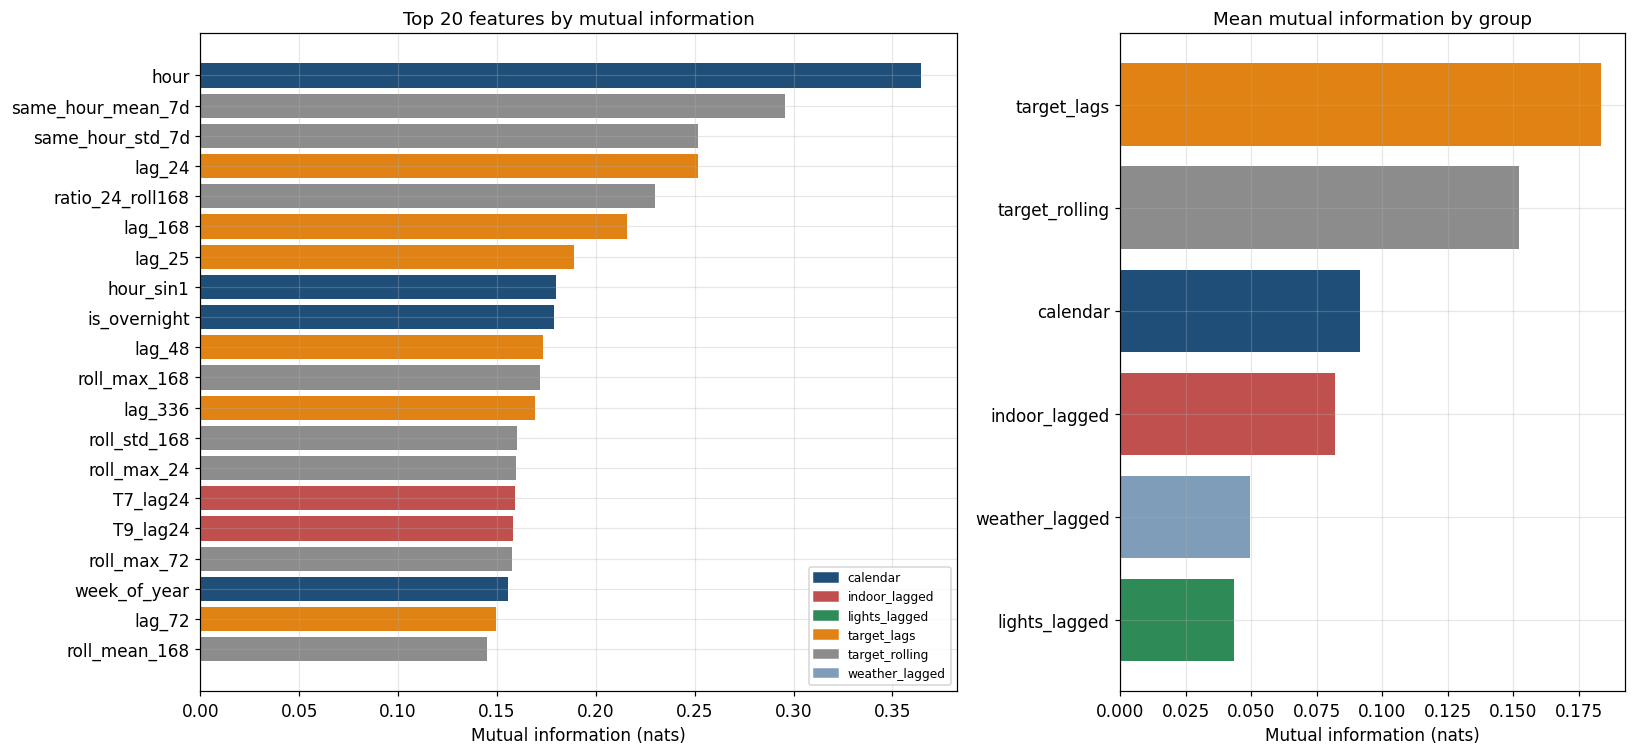

In [12]:
def plot_feature_relevance(frame, group_frame, top_n=20):
    """Top features by mutual information, and group averages."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 7),
                             gridspec_kw={"width_ratios": [3, 2]})

    top = frame.head(top_n).iloc[::-1]
    palette = {name: colour for name, colour in
               zip(sorted(frame["group"].unique()),
                   [PRIMARY, SECONDARY, "#2e8b57", "#e08214", "#8c8c8c",
                    "#7f9db9", "#6a3d9a"])}
    axes[0].barh(top["feature"], top["mutual_info"],
                 color=[palette[g] for g in top["group"]])
    axes[0].set(title=f"Top {top_n} features by mutual information",
                xlabel="Mutual information (nats)")

    handles = [plt.Rectangle((0, 0), 1, 1, color=palette[g])
               for g in sorted(frame["group"].unique())]
    axes[0].legend(handles, sorted(frame["group"].unique()),
                   fontsize=8, loc="lower right")

    ordered = group_frame.sort_values("mean_mi")
    axes[1].barh(ordered.index, ordered["mean_mi"],
                 color=[palette[g] for g in ordered.index])
    axes[1].set(title="Mean mutual information by group",
                xlabel="Mutual information (nats)")

    fig.tight_layout()
    return fig


fig = plot_feature_relevance(relevance, group_relevance)
fig.savefig(FIGURE_DIR / "18_feature_relevance.png")
plt.show()


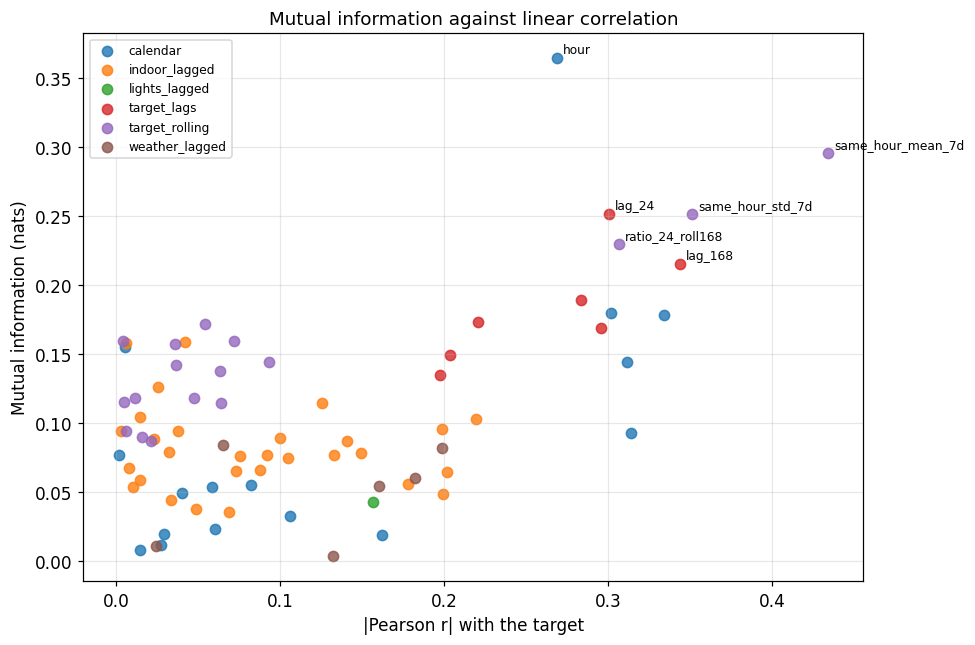

Strongest by correlation      : same_hour_mean_7d (r = 0.434, MI = 0.296)
Strongest by mutual information: hour (r = 0.269, MI = 0.364)


In [13]:
def plot_mi_vs_correlation(frame):
    """Features where mutual information and linear correlation disagree."""
    fig, ax = plt.subplots(figsize=(9, 6))

    for group, subset in frame.groupby("group"):
        ax.scatter(subset["abs_corr"], subset["mutual_info"],
                   label=group, alpha=0.8, s=45)

    for _, row in frame.head(6).iterrows():
        ax.annotate(row["feature"], (row["abs_corr"], row["mutual_info"]),
                    fontsize=8, xytext=(4, 3), textcoords="offset points")

    ax.set(title="Mutual information against linear correlation",
           xlabel="|Pearson r| with the target",
           ylabel="Mutual information (nats)")
    ax.legend(fontsize=8)

    fig.tight_layout()
    return fig


fig = plot_mi_vs_correlation(relevance)
fig.savefig(FIGURE_DIR / "19_mi_vs_correlation.png")
plt.show()

strongest_linear = relevance.loc[relevance["abs_corr"].idxmax()]
strongest_mi = relevance.iloc[0]
print(f"Strongest by correlation      : {strongest_linear['feature']} "
      f"(r = {strongest_linear['abs_corr']:.3f}, "
      f"MI = {strongest_linear['mutual_info']:.3f})")
print(f"Strongest by mutual information: {strongest_mi['feature']} "
      f"(r = {strongest_mi['abs_corr']:.3f}, "
      f"MI = {strongest_mi['mutual_info']:.3f})")


## 8. Multicollinearity among the sensor channels

Nine indoor temperature channels in a house will move together, and highly
correlated inputs make tree-based feature importances unreliable: the model
splits arbitrarily among near-duplicates and the importance is divided between
them. Quantifying the redundancy here explains why the aggregated features in
section 4 were built, and it forewarns the interpretation in Part 6.


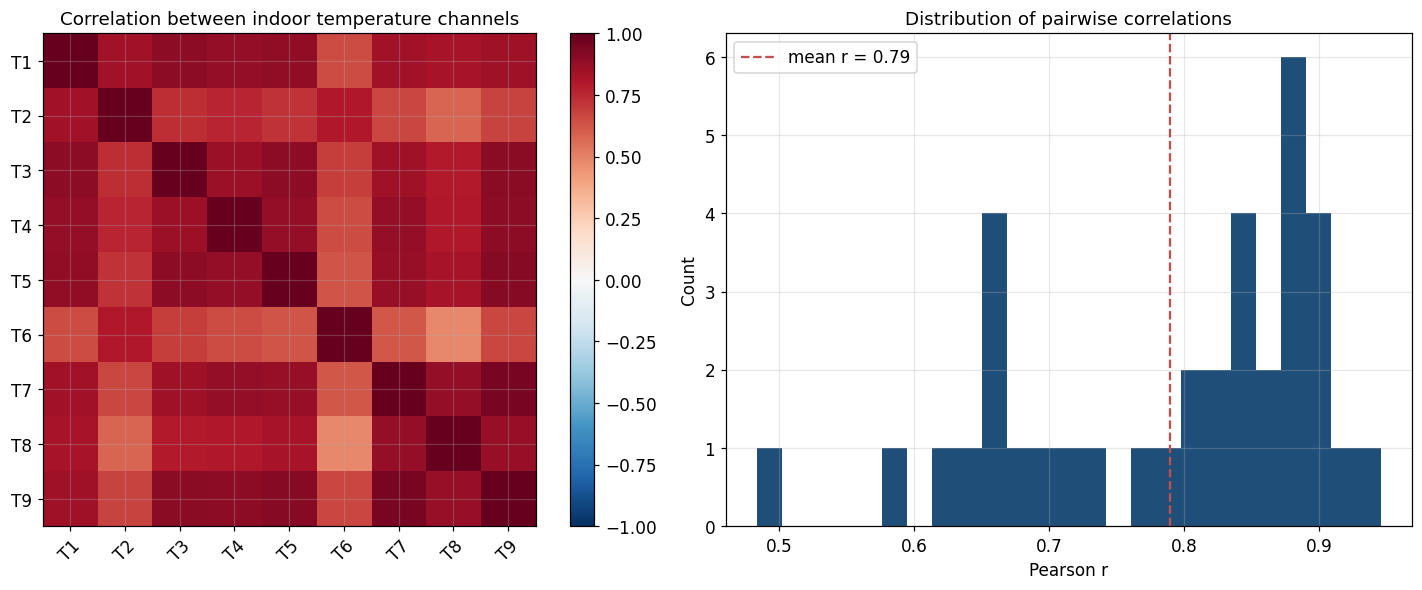

Mean pairwise correlation among the nine indoor temperatures: 0.789
Pairs above r = 0.9: 3 of 36


In [14]:
sensor_correlation = hourly[INDOOR_TEMP].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

image = axes[0].imshow(sensor_correlation, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set(title="Correlation between indoor temperature channels",
            xticks=range(len(INDOOR_TEMP)), yticks=range(len(INDOOR_TEMP)))
axes[0].set_xticklabels(INDOOR_TEMP, rotation=45)
axes[0].set_yticklabels(INDOOR_TEMP)
fig.colorbar(image, ax=axes[0], fraction=0.046)

upper = sensor_correlation.where(
    np.triu(np.ones(sensor_correlation.shape), k=1).astype(bool)).stack()
axes[1].hist(upper, bins=25, color=PRIMARY)
axes[1].axvline(upper.mean(), color=SECONDARY, linestyle="--",
                label=f"mean r = {upper.mean():.2f}")
axes[1].set(title="Distribution of pairwise correlations",
            xlabel="Pearson r", ylabel="Count")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "20_sensor_multicollinearity.png")
plt.show()

print(f"Mean pairwise correlation among the nine indoor temperatures: "
      f"{upper.mean():.3f}")
print(f"Pairs above r = 0.9: {(upper > 0.9).sum()} of {len(upper)}")


## 9. Summary of Part 5

Two feature tables built and saved, both tested for leakage.

| | Regime A | Regime B |
|---|---|---|
| Purpose | Operational forecast | Conditional upper bound |
| Rows | 2,953 | 2,953 |
| Features | 89 | 124 |
| Future covariates | none | 35 |

**Feature groups in Regime A**

- Calendar: hour, day of week, week of year, weekend and daypart flags, three
  hour harmonics, day-of-week harmonics
- Target lags: 24, 25, 26, 48, 72, 168, 336 hours
- Target rolling statistics: mean, standard deviation, min and max over 24, 72
  and 168 hour windows, all shifted 24 hours first; same-hour weekly averages;
  cycle-to-cycle differences
- Indoor sensors, lagged 24 hours: nine temperatures, nine humidities, plus
  aggregates and spreads
- Weather, lagged 24 hours: six channels plus temperature gradient and dew
  point depression
- Lights, lagged 24 hours

**All 8 leakage tests pass**, including the decisive check that a feature row
rebuilt from truncated history is identical to the row built with the full
dataset available.

**Files written**

- `outputs/processed/features_regime_a.csv`, `features_regime_b.csv`
- `outputs/metrics/part5_feature_groups.csv`, `part5_leakage_tests.csv`
- `outputs/metrics/part5_feature_relevance.csv`, `part5_group_relevance.csv`
- `outputs/figures/18` to `20`
